#  Brazilian E-Commerce — Análisis Exploratorio de Datos (EDA)

**Dataset:** Olist Brazilian E-Commerce  
**Fuente:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce  
**Tablas:** customers, geolocation, order_items, order_payments, order_reviews, orders, products, sellers, product_category_name_translation  

---
**Objetivo:** Realizar un EDA fundamental que cubra estructura, calidad, relaciones entre tablas,  
distribuciones temporales y geográficas del ecosistema de e-commerce brasileño de Olist (2016-2018).

## 0. Configuración Inicial — Google Drive

In [ ]:
# ── Montar Google Drive ──────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# INSTRUCCIÓN: Sube los 9 CSV de Kaggle a la ruta indicada en DATA_DIR
# Ruta sugerida en tu Drive:  Mi unidad / BigData / brazilian_ecommerce /
DATA_DIR = '/content/drive/MyDrive/Maestría Arch/optimizacion dbs/datos'
print(f'Ruta de datos: {DATA_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ruta de datos: /content/drive/MyDrive/Maestría Arch/optimizacion dbs/datos


## 1. Instalación e Importación de Librerías

In [ ]:
# Instalar missingno para visualizar nulos
!pip install missingno -q

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import missingno as msno
from IPython.display import display, Markdown

# Configuración visual global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('✅ Librerías cargadas correctamente.')

✅ Librerías cargadas correctamente.


## 2. Carga de Datos

In [ ]:
# ── Carga de los 9 CSV ───────────────────────────────────────────────────────
FILES = {
    'customers'   : 'olist_customers_dataset.csv',
    'geolocation' : 'olist_geolocation_dataset.csv',
    'order_items' : 'olist_order_items_dataset.csv',
    'payments'    : 'olist_order_payments_dataset.csv',
    'reviews'     : 'olist_order_reviews_dataset.csv',
    'orders'      : 'olist_orders_dataset.csv',
    'products'    : 'olist_products_dataset.csv',
    'sellers'     : 'olist_sellers_dataset.csv',
    'categories'  : 'product_category_name_translation.csv',
}

dfs = {}
for name, fname in FILES.items():
    path = os.path.join(DATA_DIR, fname)
    dfs[name] = pd.read_csv(path)
    print(f'  ✔ {name:15s} — {dfs[name].shape[0]:>7,} filas  x  {dfs[name].shape[1]:>2} cols')

print('\n✅ Todos los archivos cargados.')

  ✔ customers       —  99,441 filas  x   5 cols
  ✔ geolocation     — 1,000,163 filas  x   5 cols
  ✔ order_items     — 112,650 filas  x   7 cols
  ✔ payments        — 103,886 filas  x   5 cols
  ✔ reviews         —  99,224 filas  x   7 cols
  ✔ orders          —  99,441 filas  x   8 cols
  ✔ products        —  32,951 filas  x   9 cols
  ✔ sellers         —   3,095 filas  x   4 cols
  ✔ categories      —      71 filas  x   2 cols

✅ Todos los archivos cargados.


## 3. Estructura de Cada Tabla (`df.info()` + `df.describe()`)

In [ ]:
# ── Resumen compacto de todas las tablas ────────────────────────────────────
summary_rows = []
for name, df in dfs.items():
    summary_rows.append({
        'Tabla'          : name,
        'Filas'          : df.shape[0],
        'Columnas'       : df.shape[1],
        'Nulos totales'  : df.isnull().sum().sum(),
        '% Nulos'        : round(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2),
        'Duplicados'     : df.duplicated().sum(),
        'Memoria (KB)'   : round(df.memory_usage(deep=True).sum() / 1024, 1),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Tabla')
display(summary_df.style.background_gradient(cmap='YlOrRd', subset=['% Nulos'])
                        .format({'Filas': '{:,}', 'Duplicados': '{:,}', 'Memoria (KB)': '{:,.1f}'}))


,Filas,Columnas,Nulos totales,% Nulos,Duplicados,Memoria (KB)
Tabla,,,,,,
customers,"99,441",5,0,0.000000,0,"27,224.5"
geolocation,"1,000,163",5,0,0.000000,"261,831","133,391.2"
order_items,"112,650",7,0,0.000000,0,"36,853.4"
payments,"103,886",5,0,0.000000,0,"16,618.9"
reviews,"99,224",7,145903,21.010000,0,"40,063.8"
orders,"99,441",8,4908,0.620000,0,"54,207.8"
products,"32,951",9,2448,0.830000,0,"6,447.7"
sellers,"3,095",4,0,0.000000,0,602.2
categories,71,2,0,0.000000,0,9.2


In [ ]:
# ── df.info() individual por tabla ──────────────────────────────────────────
for name, df in dfs.items():
    display(Markdown(f'### `{name}`'))
    df.info(memory_usage='deep')
    print()

### `customers`

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 26.6 MB



### `geolocation`

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 130.3 MB



### `order_items`

...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 6.3 MB



### `sellers`

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 602.2 KB



### `categories`

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 9.2 KB



In [ ]:
# ── df.describe() para tablas con columnas numéricas relevantes ─────────────
for name in ['order_items', 'payments', 'reviews', 'products']:
    display(Markdown(f'### `{name}` — Estadísticas descriptivas'))
    display(dfs[name].describe())

### `order_items` — Estadísticas descriptivas

,order_item_id,price,freight_value
count,"112,650.00","112,650.00","112,650.00"
mean,1.20,120.65,19.99
std,0.71,183.63,15.81
min,1.00,0.85,0.00
25%,1.00,39.90,13.08
50%,1.00,74.99,16.26
75%,1.00,134.90,21.15
max,21.00,"6,735.00",409.68


### `payments` — Estadísticas descriptivas

,payment_sequential,payment_installments,payment_value
count,"103,886.00","103,886.00","103,886.00"
mean,1.09,2.85,154.10
std,0.71,2.69,217.49
min,1.00,0.00,0.00
25%,1.00,1.00,56.79
50%,1.00,1.00,100.00
75%,1.00,4.00,171.84
max,29.00,24.00,"13,664.08"


### `reviews` — Estadísticas descriptivas

,review_score
count,"99,224.00"
mean,4.09
std,1.35
min,1.00
25%,4.00
50%,5.00
75%,5.00
max,5.00


### `products` — Estadísticas descriptivas

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,"32,341.00","32,341.00","32,341.00","32,949.00","32,949.00","32,949.00","32,949.00"
mean,48.48,771.50,2.19,"2,276.47",30.82,16.94,23.20
std,10.25,635.12,1.74,"4,282.04",16.91,13.64,12.08
min,5.00,4.00,1.00,0.00,7.00,2.00,6.00
25%,42.00,339.00,1.00,300.00,18.00,8.00,15.00
50%,51.00,595.00,1.00,700.00,25.00,13.00,20.00
75%,57.00,972.00,3.00,"1,900.00",38.00,21.00,30.00
max,76.00,"3,992.00",20.00,"40,425.00",105.00,105.00,118.00


## 4. Relaciones entre Tablas — Modelo de Datos

In [ ]:
# ── Verificar integridad referencial ────────────────────────────────────────
orders = dfs['orders']
items  = dfs['order_items']
pays   = dfs['payments']
revs   = dfs['reviews']
custs  = dfs['customers']
prods  = dfs['products']
sellers= dfs['sellers']
geo    = dfs['geolocation']
cats   = dfs['categories']

checks = [
    ('orders → customers',
     orders['customer_id'].isin(custs['customer_id']).all()),
    ('order_items → orders',
     items['order_id'].isin(orders['order_id']).all()),
    ('order_items → products',
     items['product_id'].isin(prods['product_id']).all()),
    ('order_items → sellers',
     items['seller_id'].isin(sellers['seller_id']).all()),
    ('payments → orders',
     pays['order_id'].isin(orders['order_id']).all()),
    ('reviews → orders',
     revs['order_id'].isin(orders['order_id']).all()),
]

for rel, ok in checks:
    status = '✅' if ok else '❌'
    print(f'  {status}  {rel}')

# Cardinalidad
print(f'\n  📦 Órdenes con ≥1 ítem    : {items["order_id"].nunique():,}')
print(f'  💳 Órdenes con ≥1 pago    : {pays["order_id"].nunique():,}')
print(f'  ⭐ Órdenes con ≥1 reseña  : {revs["order_id"].nunique():,}')
print(f'  👥 Clientes únicos        : {custs["customer_id"].nunique():,}')
print(f'  🏪 Vendedores únicos      : {sellers["seller_id"].nunique():,}')
print(f'  📦 Productos únicos       : {prods["product_id"].nunique():,}')

  ✅  orders → customers
  ✅  order_items → orders
  ✅  order_items → products
  ✅  order_items → sellers
  ✅  payments → orders
  ✅  reviews → orders

  📦 Órdenes con ≥1 ítem    : 98,666
  💳 Órdenes con ≥1 pago    : 99,440
  ⭐ Órdenes con ≥1 reseña  : 98,673
  👥 Clientes únicos        : 99,441
  🏪 Vendedores únicos      : 3,095
  📦 Productos únicos       : 32,951


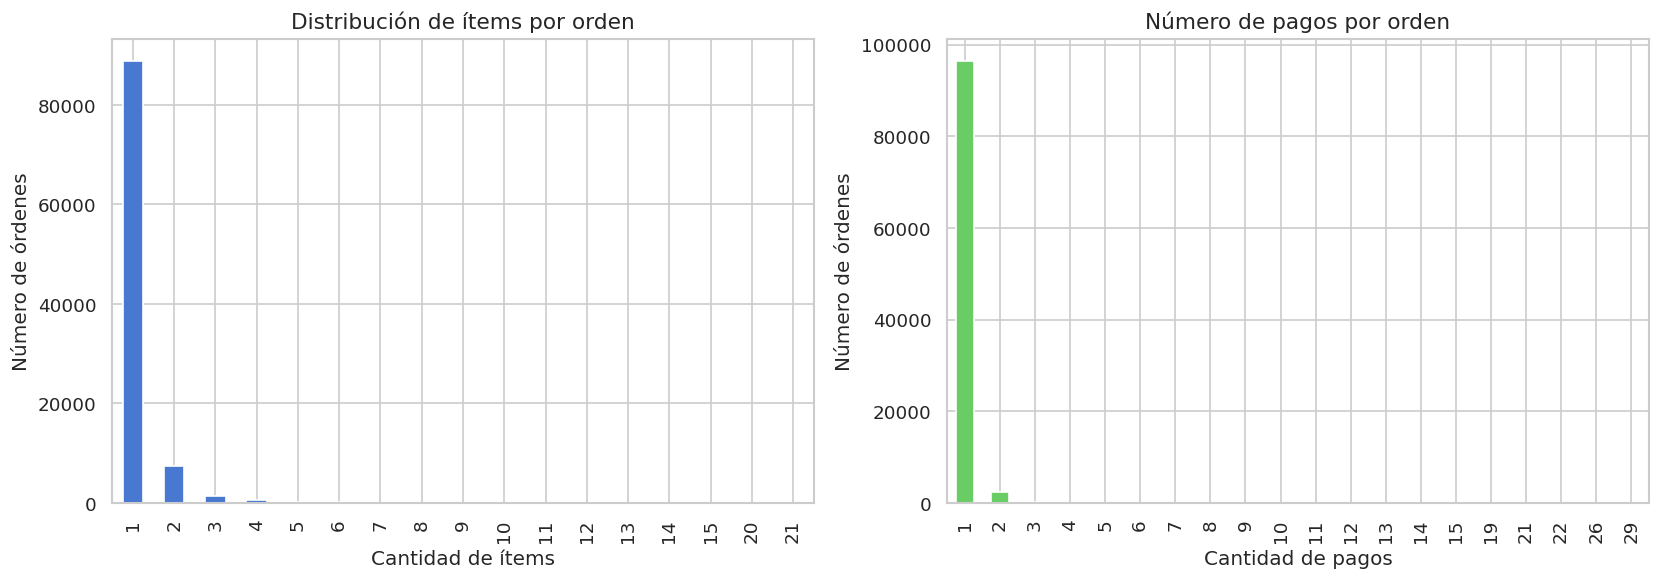

In [ ]:
# ── Ítems por orden ──────────────────────────────────────────────────────────
items_per_order = items.groupby('order_id')['order_item_id'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
items_per_order.value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].set_title('Distribución de ítems por orden', fontsize=13)
axes[0].set_xlabel('Cantidad de ítems')
axes[0].set_ylabel('Número de órdenes')

pays.groupby('order_id')['payment_sequential'].count().value_counts().sort_index() \
    .plot(kind='bar', ax=axes[1], color=sns.color_palette('muted')[2], edgecolor='white')
axes[1].set_title('Número de pagos por orden', fontsize=13)
axes[1].set_xlabel('Cantidad de pagos')
axes[1].set_ylabel('Número de órdenes')

plt.tight_layout()
plt.show()

## 5. Calidad de Datos — Análisis de Valores Nulos

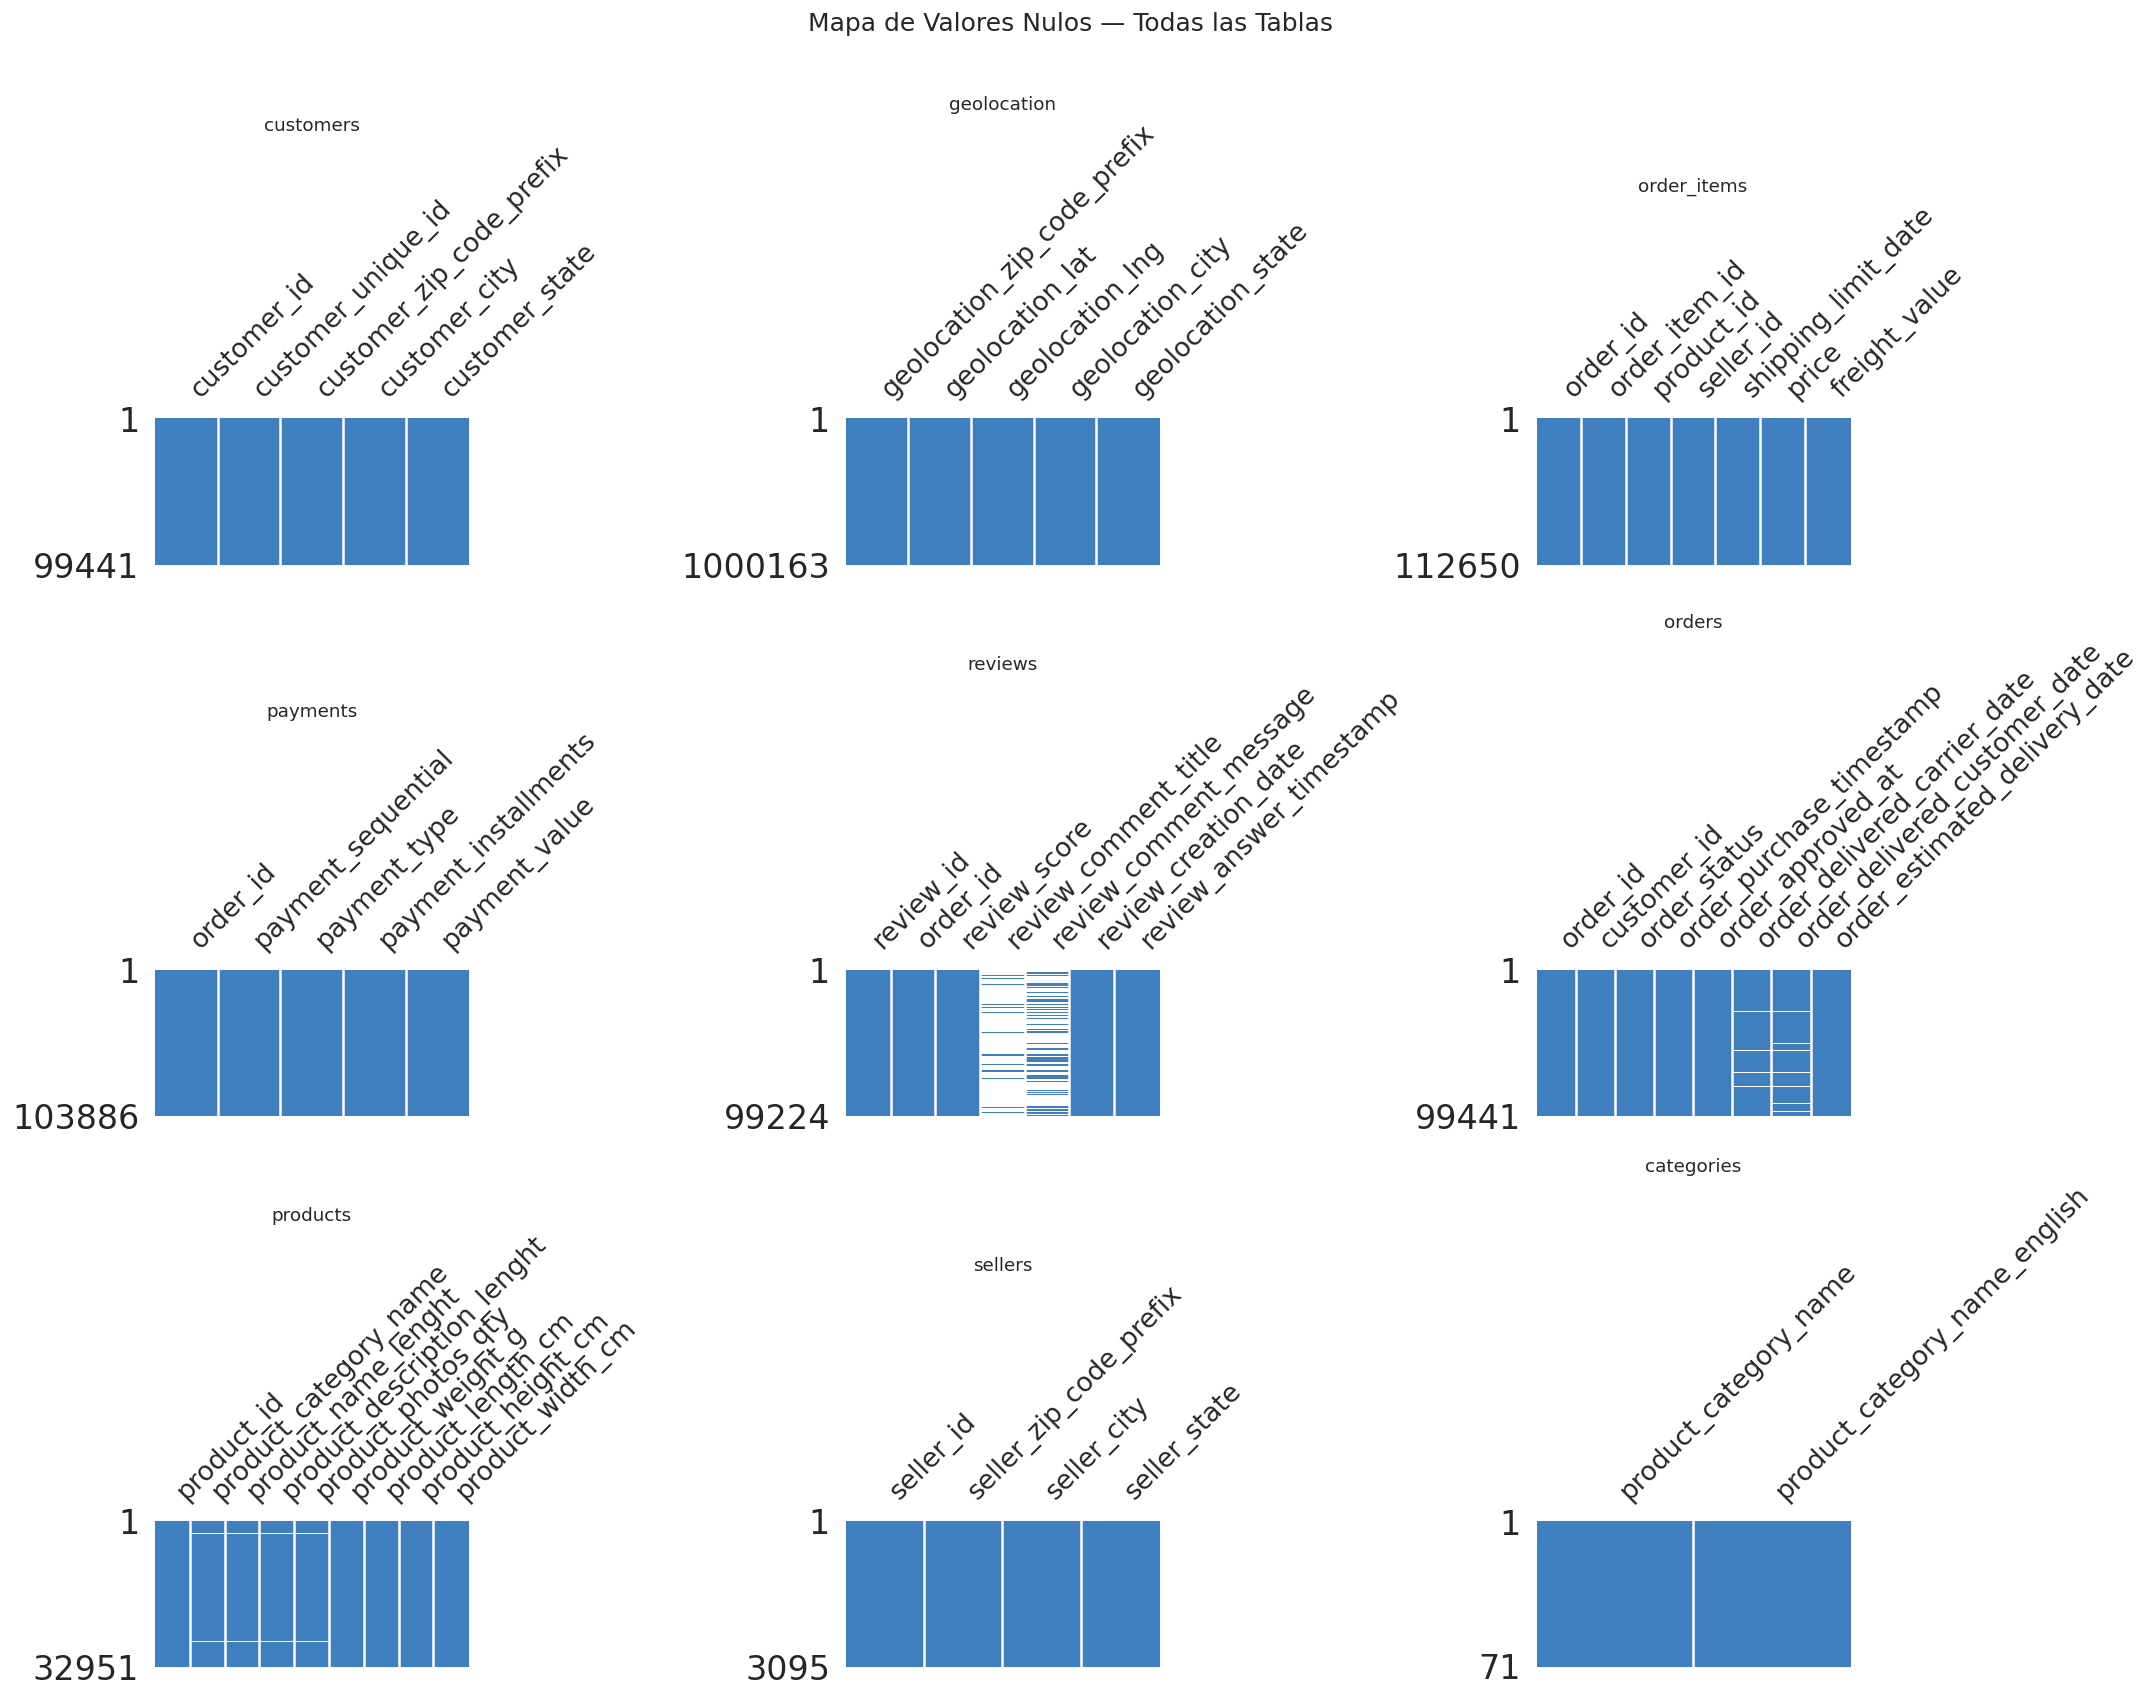

In [ ]:
# ── Mapa de nulos por tabla ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, (name, df) in enumerate(dfs.items()):
    msno.matrix(df, ax=axes[idx], sparkline=False, color=(0.25, 0.50, 0.75))
    axes[idx].set_title(f'{name}', fontsize=11)

plt.suptitle('Mapa de Valores Nulos — Todas las Tablas', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ── Detalle de nulos por columna ────────────────────────────────────────────
null_detail = []
for name, df in dfs.items():
    for col in df.columns:
        n = df[col].isnull().sum()
        if n > 0:
            null_detail.append({'Tabla': name, 'Columna': col,
                                 'Nulos': n, '% Nulos': round(n/len(df)*100, 2)})

null_df = pd.DataFrame(null_detail).sort_values('% Nulos', ascending=False)
display(null_df.style.background_gradient(cmap='Reds', subset=['% Nulos'])
                     .format({'Nulos': '{:,}', '% Nulos': '{:.2f}%'}))

,Tabla,Columna,Nulos,% Nulos
0,reviews,review_comment_title,"87,656",88.34%
1,reviews,review_comment_message,"58,247",58.70%
4,orders,order_delivered_customer_date,"2,965",2.98%
6,products,product_name_lenght,610,1.85%
5,products,product_category_name,610,1.85%
7,products,product_description_lenght,610,1.85%
8,products,product_photos_qty,610,1.85%
3,orders,order_delivered_carrier_date,"1,783",1.79%
2,orders,order_approved_at,160,0.16%
9,products,product_weight_g,2,0.01%


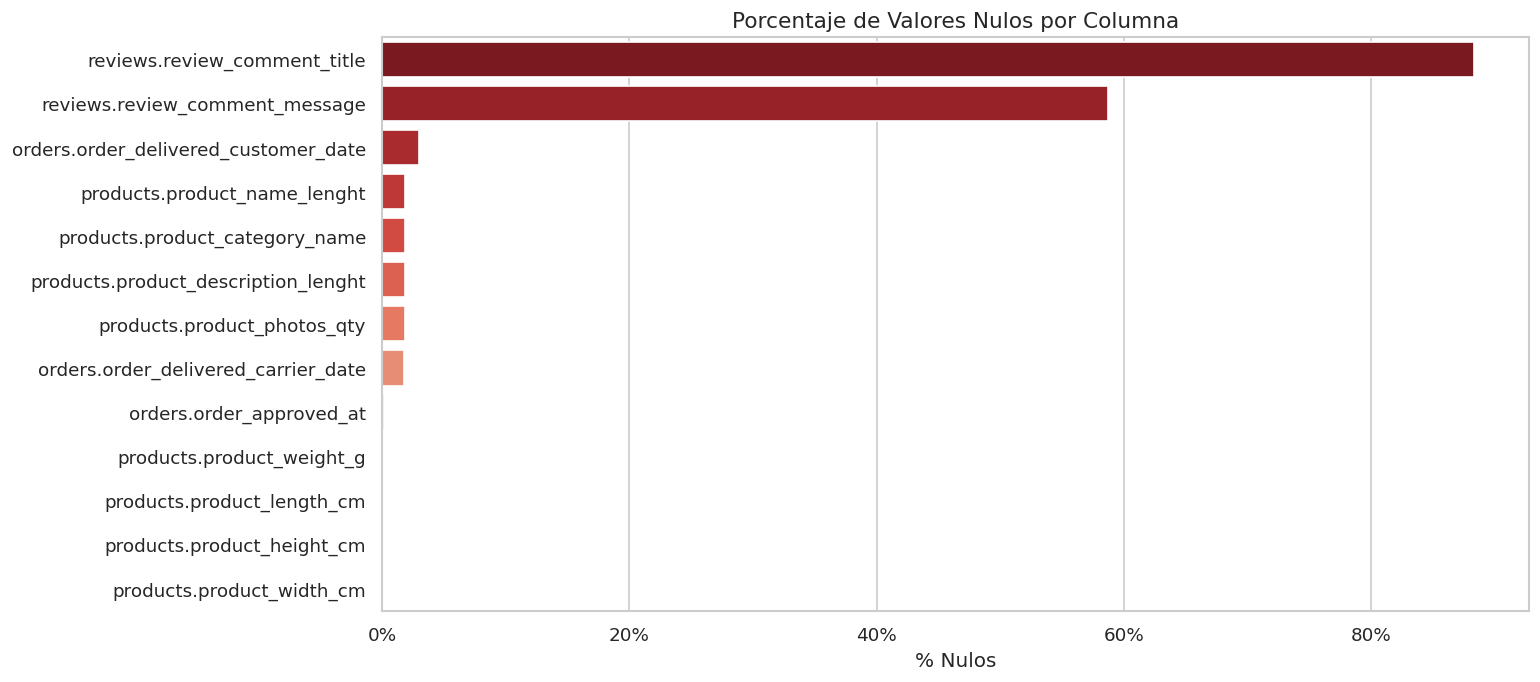

In [ ]:
# ── Gráfico de barras: % nulos por columna (sólo las afectadas) ─────────────
if not null_df.empty:
    null_df['Tabla_Columna'] = null_df['Tabla'] + '.' + null_df['Columna']
    fig, ax = plt.subplots(figsize=(13, max(5, len(null_df)*0.45)))
    sns.barplot(data=null_df, y='Tabla_Columna', x='% Nulos', palette='Reds_r', ax=ax)
    ax.set_title('Porcentaje de Valores Nulos por Columna', fontsize=13)
    ax.set_xlabel('% Nulos')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    plt.tight_layout()
    plt.show()

## 6. Análisis Temporal — Distribución de Órdenes

In [ ]:
# ── Conversión de fechas ─────────────────────────────────────────────────────
date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders['year']       = orders['order_purchase_timestamp'].dt.year
orders['month']      = orders['order_purchase_timestamp'].dt.month
orders['dow']        = orders['order_purchase_timestamp'].dt.dayofweek   # 0=Lunes
orders['hour']       = orders['order_purchase_timestamp'].dt.hour

print(f'Periodo cubierto: {orders["order_purchase_timestamp"].min().date()}'
      f' → {orders["order_purchase_timestamp"].max().date()}')
print(f'Total órdenes   : {len(orders):,}')

Periodo cubierto: 2016-09-04 → 2018-10-17
Total órdenes   : 99,441


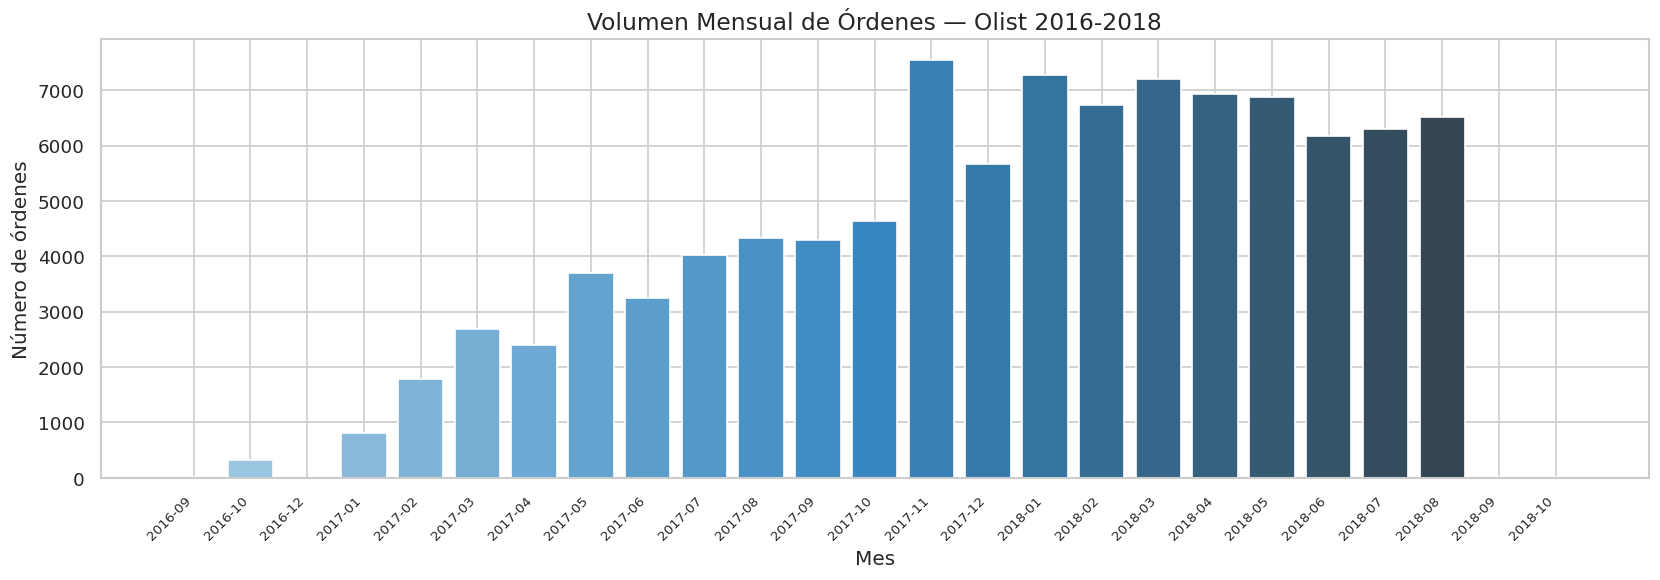

In [ ]:
# ── Serie temporal mensual ──────────────────────────────────────────────────
monthly = orders.groupby('year_month').size().reset_index(name='orders')
monthly['year_month_str'] = monthly['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly['year_month_str'], monthly['orders'],
       color=sns.color_palette('Blues_d', len(monthly)), edgecolor='white')
ax.set_title('Volumen Mensual de Órdenes — Olist 2016-2018', fontsize=14)
ax.set_xlabel('Mes')
ax.set_ylabel('Número de órdenes')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

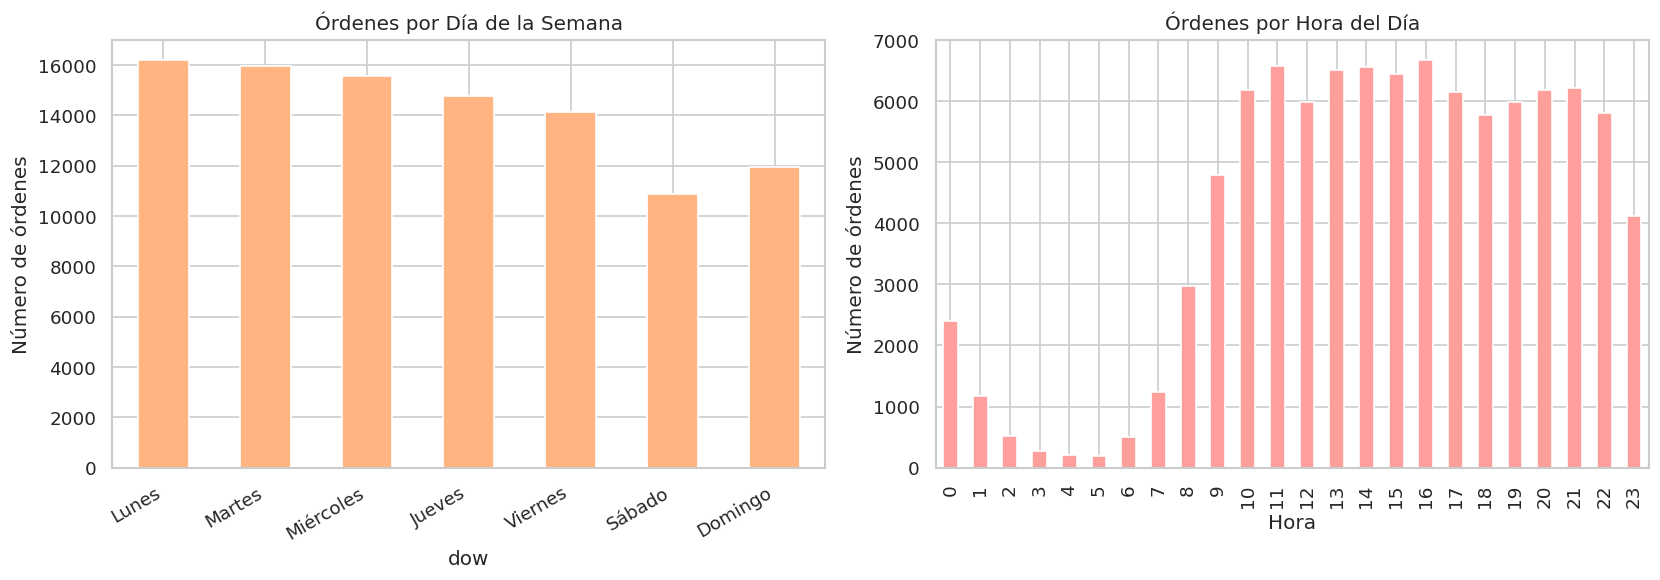

In [ ]:
# ── Distribución por día de la semana y hora del día ────────────────────────
dow_labels = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orders['dow'].value_counts().reindex(range(7)).plot(
    kind='bar', ax=axes[0], color=sns.color_palette('pastel')[1], edgecolor='white')
axes[0].set_xticklabels(dow_labels, rotation=30, ha='right')
axes[0].set_title('Órdenes por Día de la Semana', fontsize=12)
axes[0].set_ylabel('Número de órdenes')

orders['hour'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=sns.color_palette('pastel')[3], edgecolor='white')
axes[1].set_title('Órdenes por Hora del Día', fontsize=12)
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Número de órdenes')

plt.tight_layout()
plt.show()

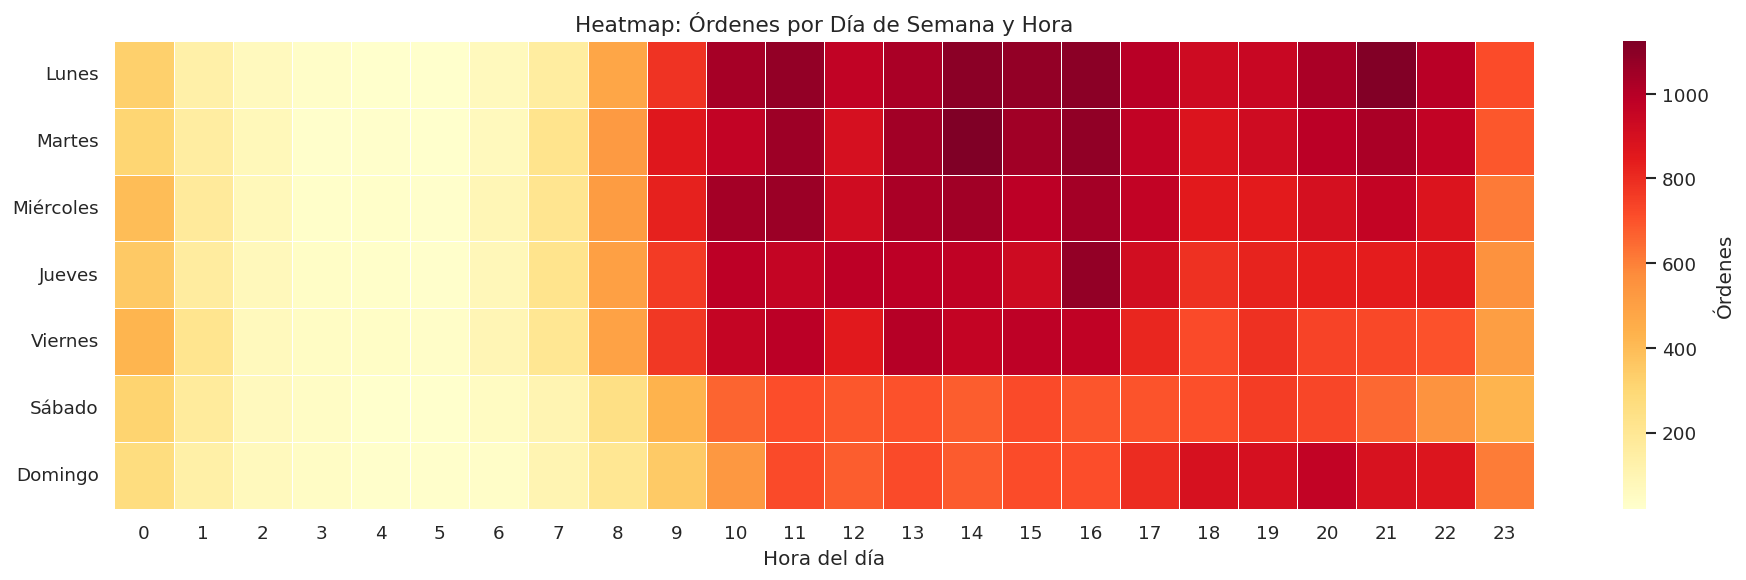

In [ ]:
# ── Heatmap día de semana × hora ────────────────────────────────────────────
heatmap_data = orders.groupby(['dow', 'hour']).size().unstack(fill_value=0)
heatmap_data.index = dow_labels

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=.3, ax=ax,
            cbar_kws={'label': 'Órdenes'})
ax.set_title('Heatmap: Órdenes por Día de Semana y Hora', fontsize=13)
ax.set_xlabel('Hora del día')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

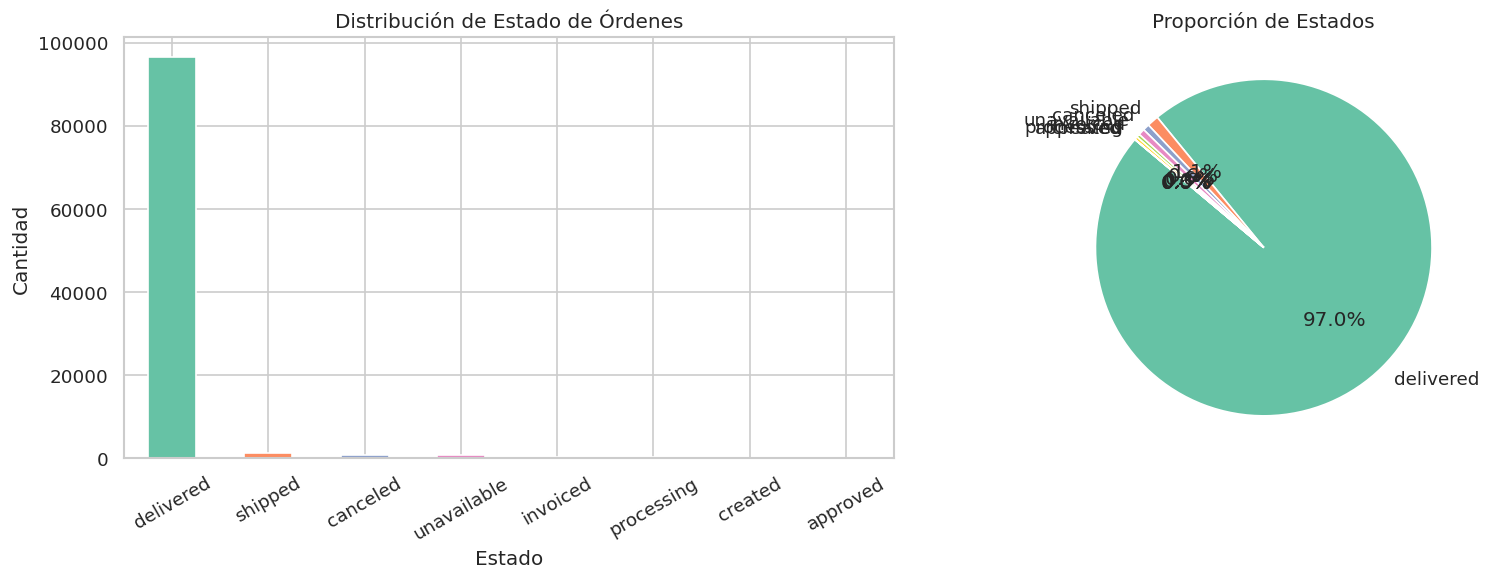

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2


In [ ]:
# ── Estado de las órdenes ───────────────────────────────────────────────────
status_counts = orders['order_status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status_counts.plot(kind='bar', ax=axes[0],
    color=sns.color_palette('Set2', len(status_counts)), edgecolor='white')
axes[0].set_title('Distribución de Estado de Órdenes', fontsize=12)
axes[0].set_xlabel('Estado')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(status_counts)), startangle=140)
axes[1].set_title('Proporción de Estados', fontsize=12)

plt.tight_layout()
plt.show()
print(status_counts.to_string())

## 7. Análisis Geográfico

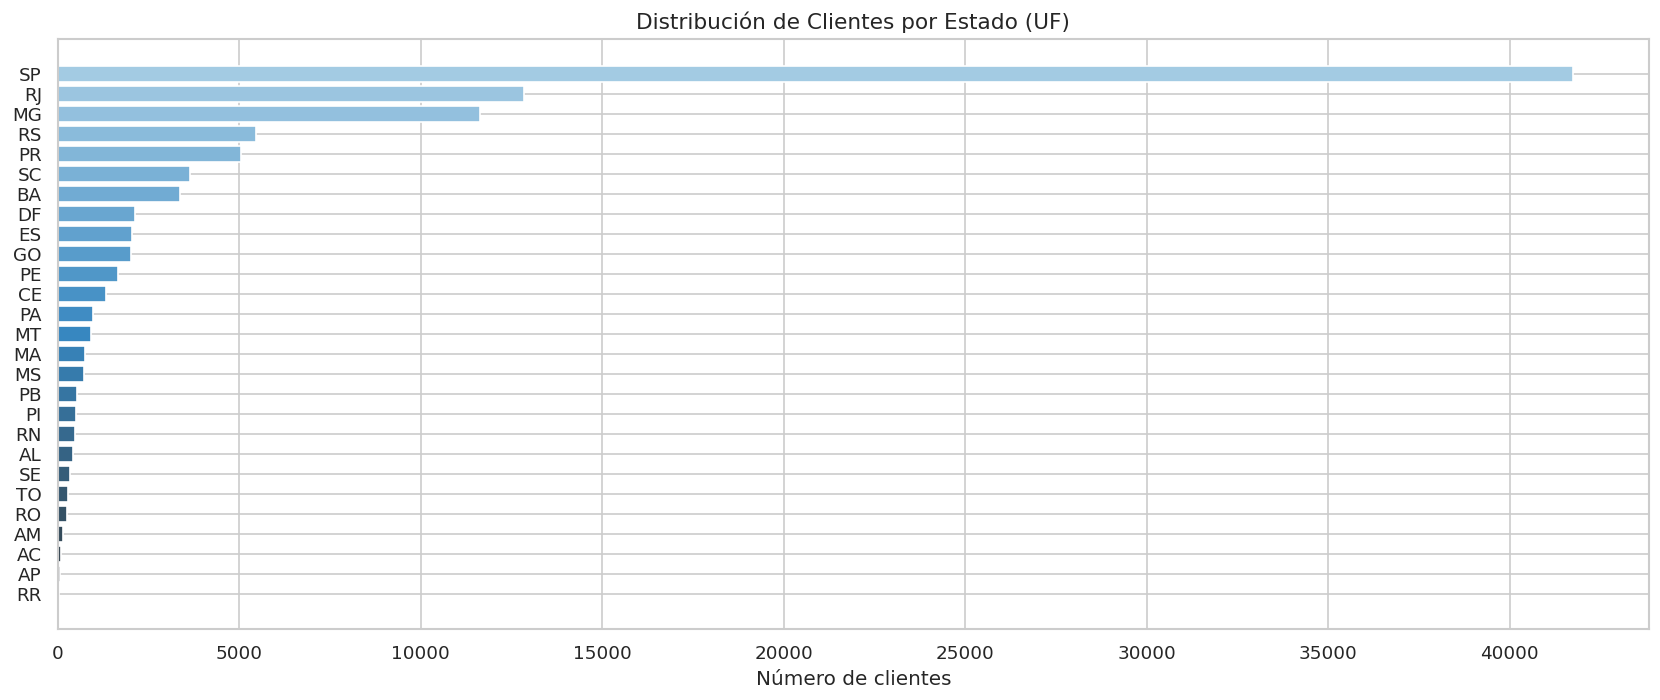

In [ ]:
# ── Clientes por estado (UF) ─────────────────────────────────────────────────
custs_state = custs['customer_state'].value_counts().reset_index()
custs_state.columns = ['Estado', 'Clientes']

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(custs_state['Estado'], custs_state['Clientes'],
               color=sns.color_palette('Blues_d', len(custs_state)))
ax.set_title('Distribución de Clientes por Estado (UF)', fontsize=13)
ax.set_xlabel('Número de clientes')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

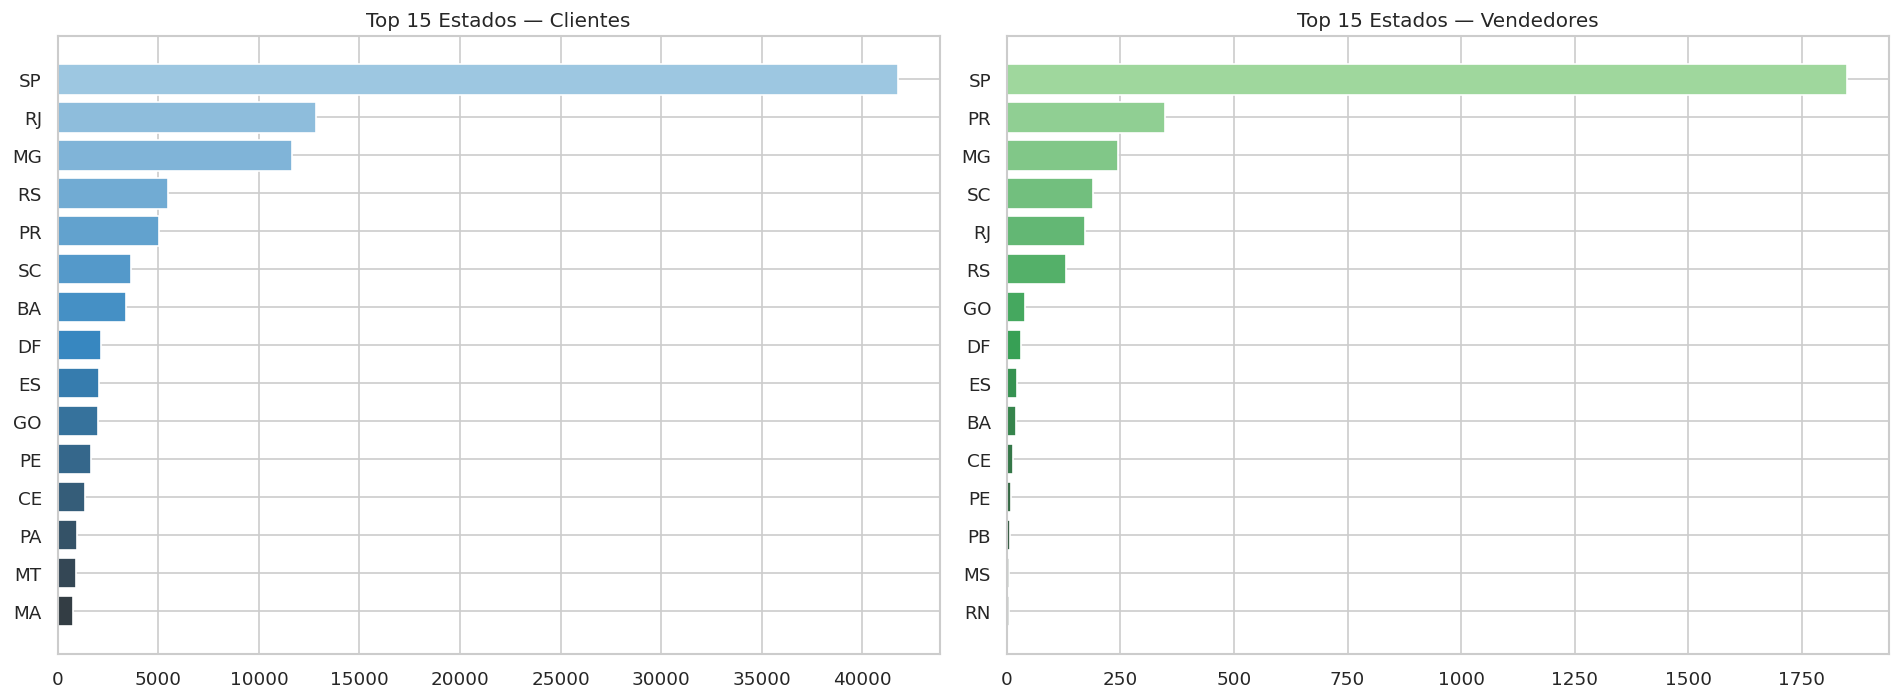

In [ ]:
# ── Vendedores por estado ────────────────────────────────────────────────────
sellers_state = sellers['seller_state'].value_counts().reset_index()
sellers_state.columns = ['Estado', 'Vendedores']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(custs_state.head(15)['Estado'], custs_state.head(15)['Clientes'],
             color=sns.color_palette('Blues_d', 15))
axes[0].set_title('Top 15 Estados — Clientes', fontsize=12)
axes[0].invert_yaxis()

axes[1].barh(sellers_state.head(15)['Estado'], sellers_state.head(15)['Vendedores'],
             color=sns.color_palette('Greens_d', 15))
axes[1].set_title('Top 15 Estados — Vendedores', fontsize=12)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

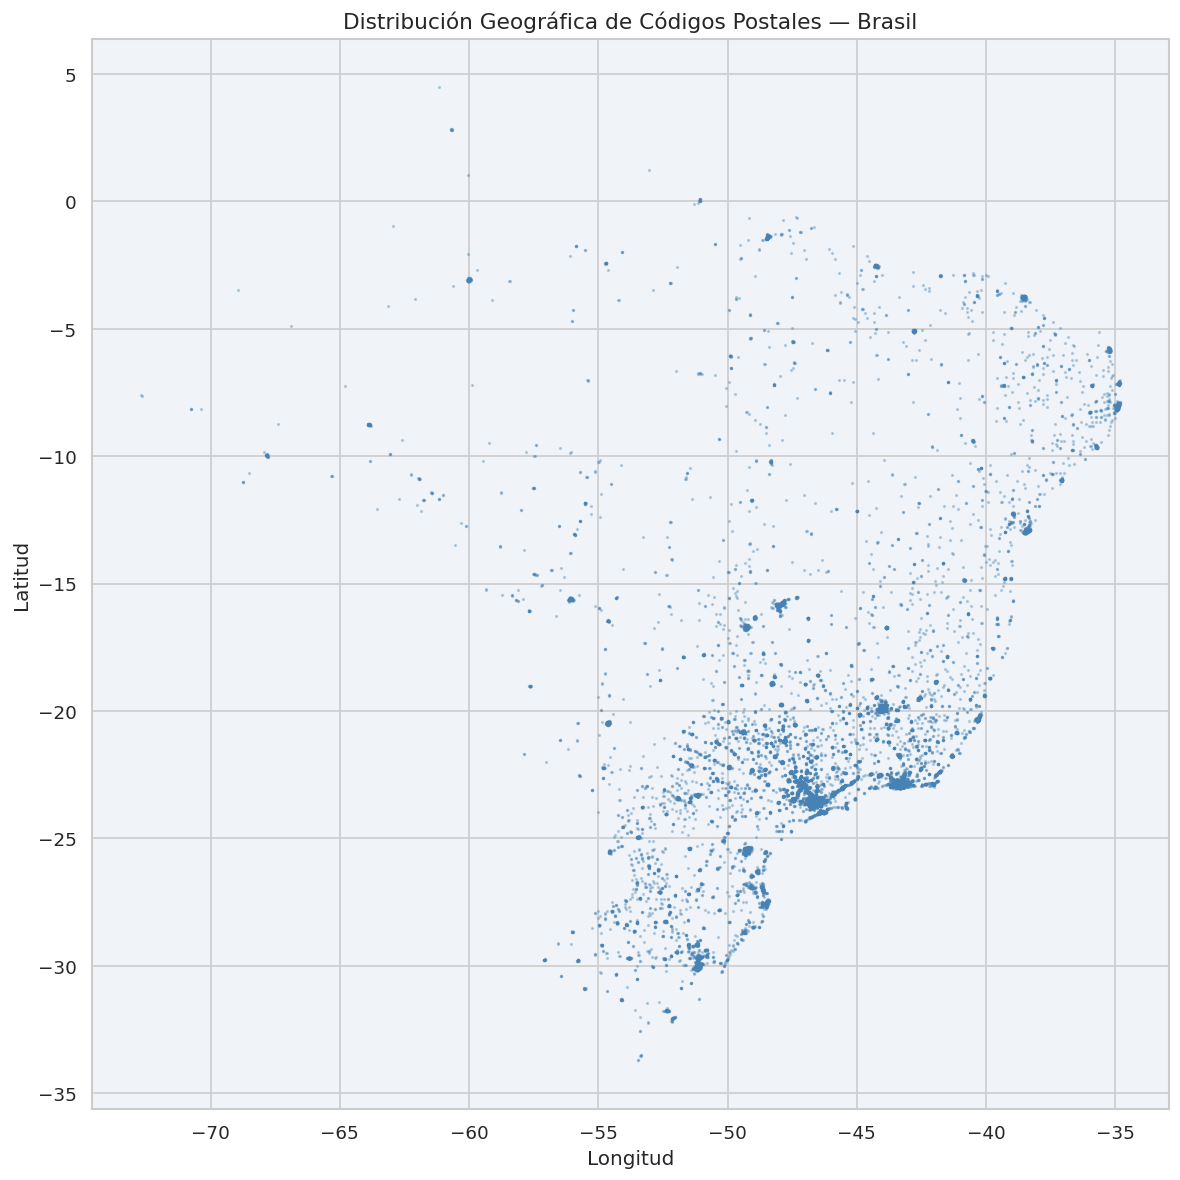

In [ ]:
# ── Mapa de puntos geográficos (sample 20k) ──────────────────────────────────
geo_sample = geo.sample(min(20_000, len(geo)), random_state=42)

# Filtrar coordenadas dentro de Brasil
geo_sample = geo_sample[
    (geo_sample['geolocation_lat'].between(-33.75, 5.27)) &
    (geo_sample['geolocation_lng'].between(-73.99, -34.73))
]

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(geo_sample['geolocation_lng'], geo_sample['geolocation_lat'],
           s=1, alpha=0.3, color='steelblue')
ax.set_title('Distribución Geográfica de Códigos Postales — Brasil', fontsize=13)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_facecolor('#f0f4f8')
plt.tight_layout()
plt.show()

## 8. Análisis de Productos y Categorías

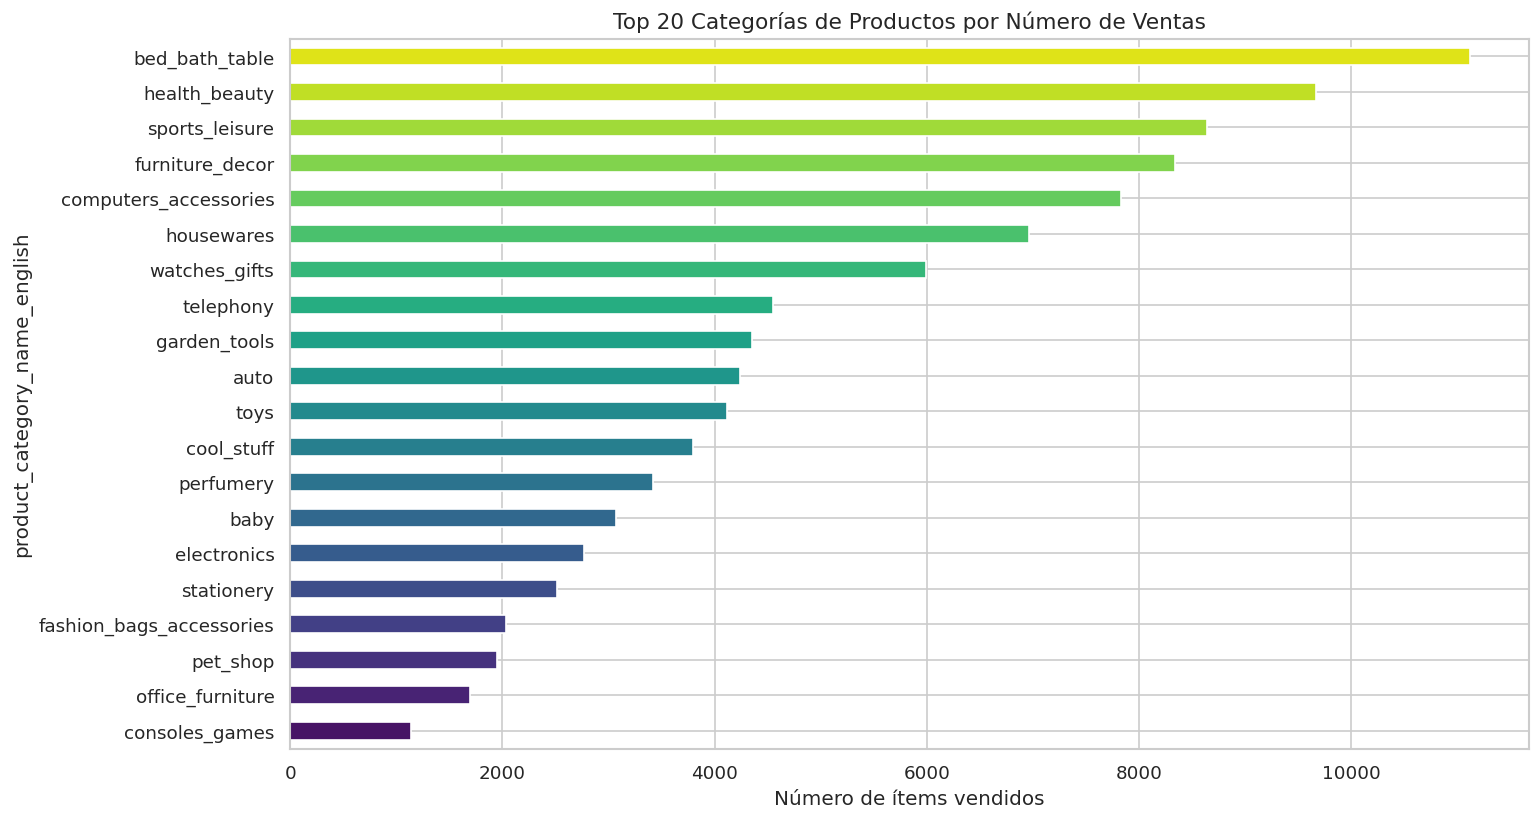

In [ ]:
# ── Merge con traducción de categorías ──────────────────────────────────────
prods_cat = prods.merge(cats, on='product_category_name', how='left')
items_ext = items.merge(prods_cat[['product_id','product_category_name_english']],
                        on='product_id', how='left')

top_cats = items_ext['product_category_name_english'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(13, 7))
top_cats.sort_values().plot(kind='barh', ax=ax,
    color=sns.color_palette('viridis', len(top_cats)), edgecolor='white')
ax.set_title('Top 20 Categorías de Productos por Número de Ventas', fontsize=13)
ax.set_xlabel('Número de ítems vendidos')
plt.tight_layout()
plt.show()

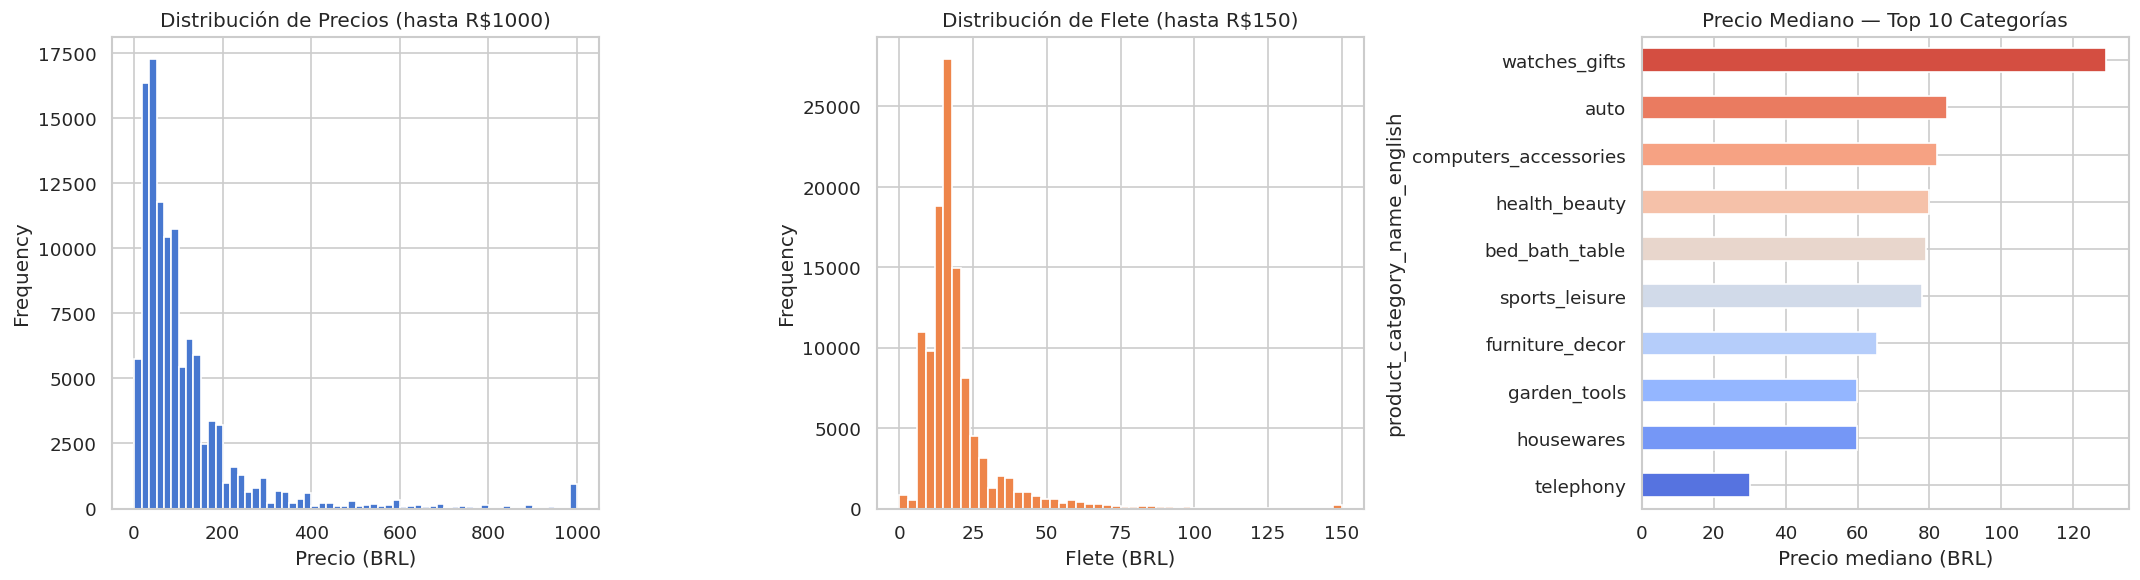

In [ ]:
# ── Análisis de precios y fletes ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

items['price'].clip(0, 1000).plot(kind='hist', bins=60, ax=axes[0],
    color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].set_title('Distribución de Precios (hasta R$1000)', fontsize=12)
axes[0].set_xlabel('Precio (BRL)')

items['freight_value'].clip(0, 150).plot(kind='hist', bins=50, ax=axes[1],
    color=sns.color_palette('muted')[1], edgecolor='white')
axes[1].set_title('Distribución de Flete (hasta R$150)', fontsize=12)
axes[1].set_xlabel('Flete (BRL)')

# Precio mediano por top 10 categorías
top10_cats = top_cats.head(10).index.tolist()
price_by_cat = items_ext[items_ext['product_category_name_english'].isin(top10_cats)] \
    .groupby('product_category_name_english')['price'].median().sort_values()

price_by_cat.plot(kind='barh', ax=axes[2],
    color=sns.color_palette('coolwarm', len(price_by_cat)), edgecolor='white')
axes[2].set_title('Precio Mediano — Top 10 Categorías', fontsize=12)
axes[2].set_xlabel('Precio mediano (BRL)')

plt.tight_layout()
plt.show()

## 9. Análisis de Pagos

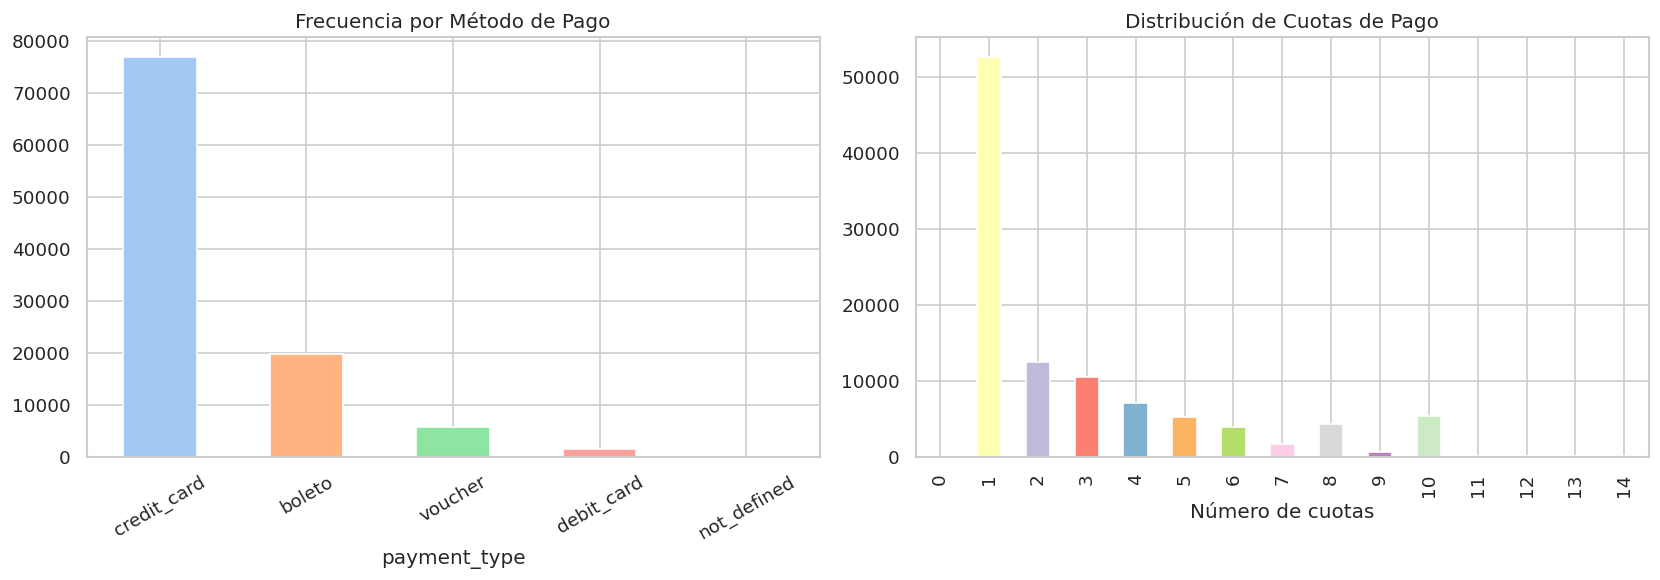


📊 Estadísticas de valor de pago:
count   103,886.00
mean        154.10
std         217.49
min           0.00
25%          56.79
50%         100.00
75%         171.84
max      13,664.08
Name: payment_value, dtype: float64


In [ ]:
# ── Métodos de pago ─────────────────────────────────────────────────────────
pay_method = pays['payment_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pay_method.plot(kind='bar', ax=axes[0],
    color=sns.color_palette('pastel'), edgecolor='white')
axes[0].set_title('Frecuencia por Método de Pago', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)

pays['payment_installments'].value_counts().sort_index().head(15).plot(
    kind='bar', ax=axes[1],
    color=sns.color_palette('Set3'), edgecolor='white')
axes[1].set_title('Distribución de Cuotas de Pago', fontsize=12)
axes[1].set_xlabel('Número de cuotas')

plt.tight_layout()
plt.show()

print('\n📊 Estadísticas de valor de pago:')
print(pays['payment_value'].describe())

## 10. Análisis de Reseñas y Satisfacción

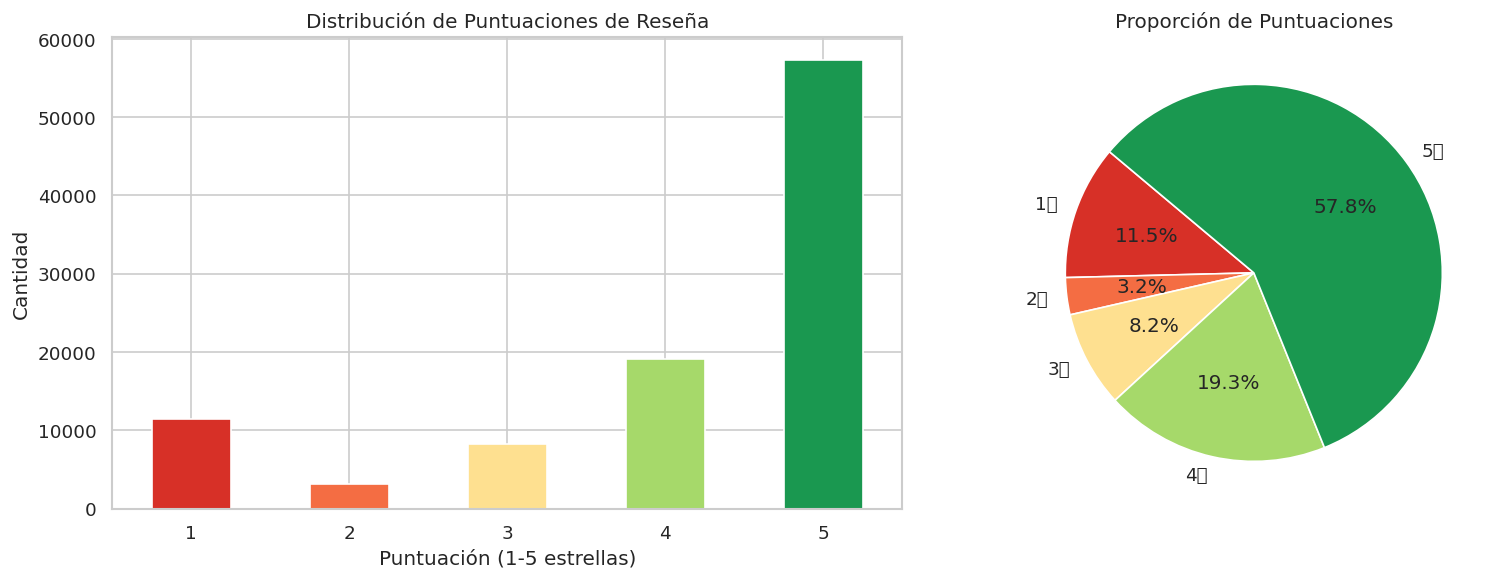


⭐ Puntuación promedio: 4.09 / 5.00
   Puntuación mediana : 5.0


In [ ]:
# ── Distribución de puntuaciones ─────────────────────────────────────────────
score_dist = revs['review_score'].value_counts().sort_index()

colors_score = ['#d73027','#f46d43','#fee090','#a6d96a','#1a9850']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

score_dist.plot(kind='bar', ax=axes[0], color=colors_score, edgecolor='white')
axes[0].set_title('Distribución de Puntuaciones de Reseña', fontsize=12)
axes[0].set_xlabel('Puntuación (1-5 estrellas)')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=0)

axes[1].pie(score_dist, labels=[f'{i}⭐' for i in score_dist.index],
            autopct='%1.1f%%', colors=colors_score, startangle=140)
axes[1].set_title('Proporción de Puntuaciones', fontsize=12)

plt.tight_layout()
plt.show()

avg_score = revs['review_score'].mean()
print(f'\n⭐ Puntuación promedio: {avg_score:.2f} / 5.00')
print(f'   Puntuación mediana : {revs["review_score"].median():.1f}')

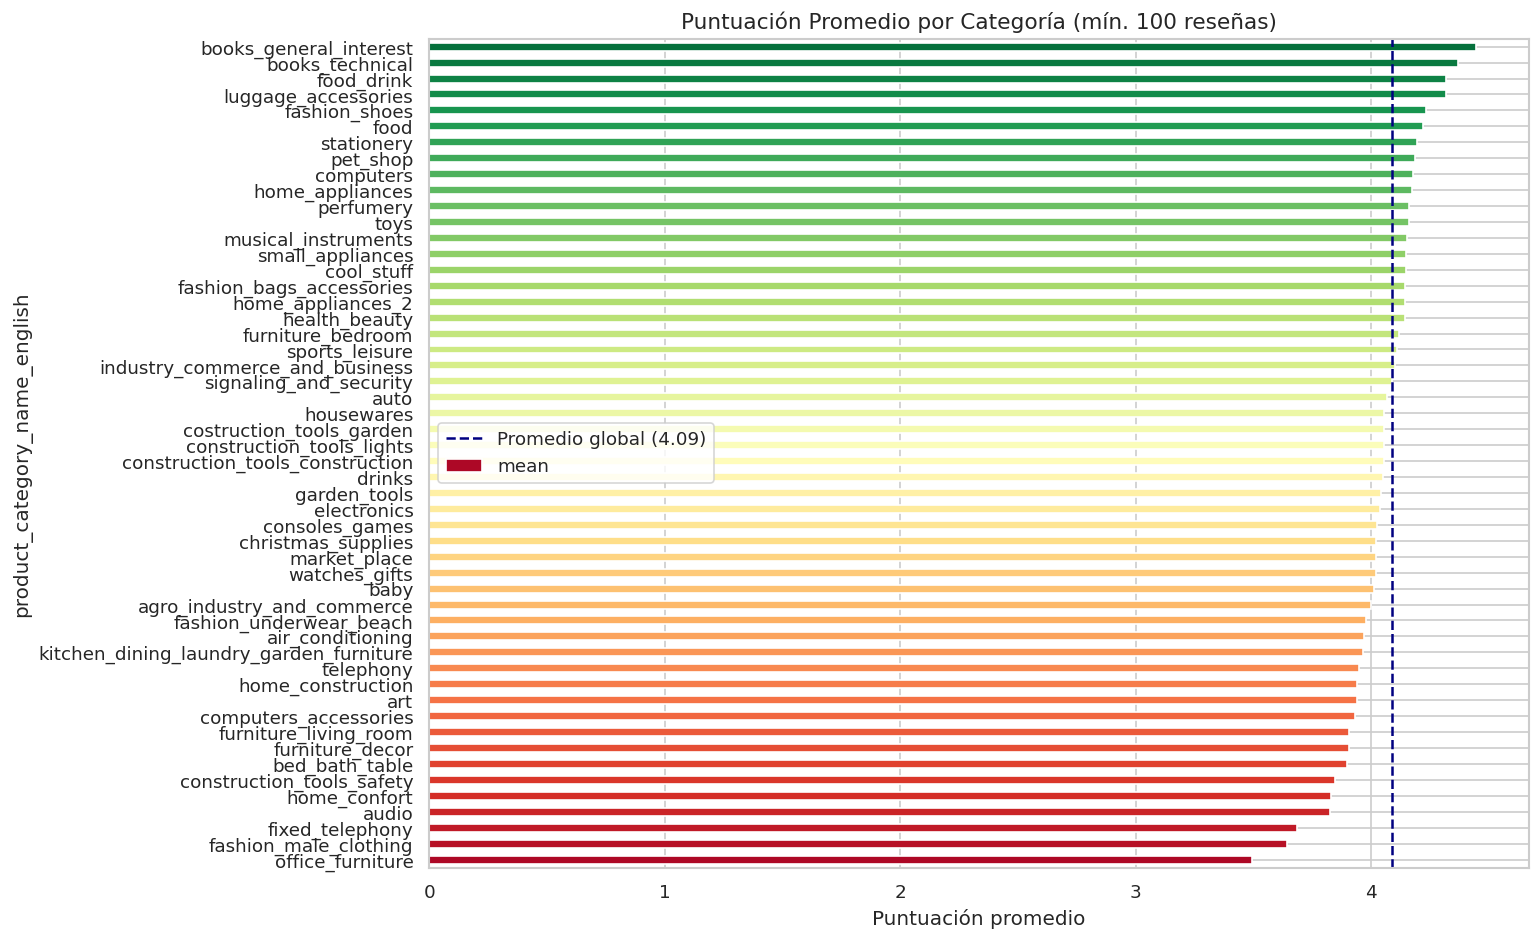

In [ ]:
# ── Satisfacción por categoría ───────────────────────────────────────────────
orders_revs = orders[['order_id']].merge(
    revs[['order_id','review_score']], on='order_id', how='inner')
items_score = items_ext.merge(orders_revs, on='order_id', how='inner')

cat_score = (
    items_score
    .groupby('product_category_name_english')['review_score']
    .agg(['mean','count'])
    .query('count >= 100')
    .sort_values('mean', ascending=True)
)

fig, ax = plt.subplots(figsize=(13, 8))
cat_score['mean'].plot(kind='barh', ax=ax,
    color=sns.color_palette('RdYlGn', len(cat_score)), edgecolor='white')
ax.axvline(avg_score, color='navy', linestyle='--', label=f'Promedio global ({avg_score:.2f})')
ax.set_title('Puntuación Promedio por Categoría (mín. 100 reseñas)', fontsize=13)
ax.set_xlabel('Puntuación promedio')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Análisis de Tiempos de Entrega

In [ ]:
# ── Calcular días de entrega real vs estimado ────────────────────────────────
delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered['delivery_days'] = (
    delivered['order_delivered_customer_date'] -
    delivered['order_purchase_timestamp']
).dt.days
delivered['estimated_days'] = (
    delivered['order_estimated_delivery_date'] -
    delivered['order_purchase_timestamp']
).dt.days
delivered['delay_days'] = delivered['delivery_days'] - delivered['estimated_days']
delivered['on_time'] = delivered['delay_days'] <= 0

on_time_pct = delivered['on_time'].mean() * 100
print(f'📦 Entregas a tiempo: {on_time_pct:.1f}%')
print(f'   Días promedio de entrega real    : {delivered["delivery_days"].mean():.1f}')
print(f'   Días promedio estimados          : {delivered["estimated_days"].mean():.1f}')
print(f'   Retraso promedio (días)          : {delivered["delay_days"].mean():.1f}')

📦 Entregas a tiempo: 92.4%
   Días promedio de entrega real    : 12.1
   Días promedio estimados          : 23.4
   Retraso promedio (días)          : -11.3


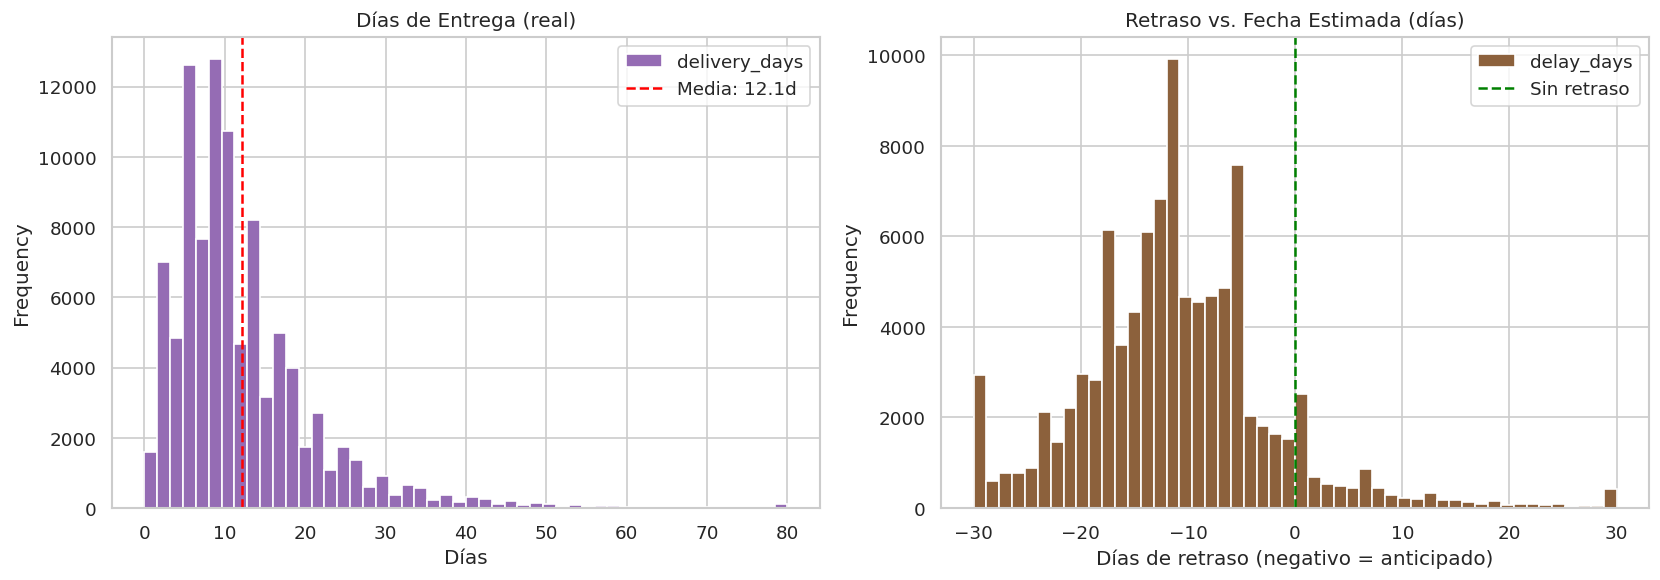

In [ ]:
# ── Distribución de días de entrega ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delivered['delivery_days'].clip(0, 80).plot(
    kind='hist', bins=50, ax=axes[0],
    color=sns.color_palette('muted')[4], edgecolor='white')
axes[0].axvline(delivered['delivery_days'].mean(), color='red', linestyle='--',
                label=f'Media: {delivered["delivery_days"].mean():.1f}d')
axes[0].set_title('Días de Entrega (real)', fontsize=12)
axes[0].set_xlabel('Días')
axes[0].legend()

delivered['delay_days'].clip(-30, 30).plot(
    kind='hist', bins=50, ax=axes[1],
    color=sns.color_palette('muted')[5], edgecolor='white')
axes[1].axvline(0, color='green', linestyle='--', label='Sin retraso')
axes[1].set_title('Retraso vs. Fecha Estimada (días)', fontsize=12)
axes[1].set_xlabel('Días de retraso (negativo = anticipado)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Dashboard de Métricas Clave (KPIs)

In [ ]:
# ── Resumen ejecutivo ────────────────────────────────────────────────────────
total_revenue = pays['payment_value'].sum()
total_orders  = orders['order_id'].nunique()
total_custs   = custs['customer_id'].nunique()
total_sellers = sellers['seller_id'].nunique()
total_prods   = prods['product_id'].nunique()
avg_review    = revs['review_score'].mean()
aov           = total_revenue / total_orders   # Average Order Value

kpis = {
    '💰 Ingresos Totales (BRL)'   : f'R$ {total_revenue:,.0f}',
    '🛒 Total de Órdenes'         : f'{total_orders:,}',
    '👥 Clientes Únicos'          : f'{total_custs:,}',
    '🏪 Vendedores'               : f'{total_sellers:,}',
    '📦 Productos Únicos'         : f'{total_prods:,}',
    '⭐ Satisfacción Promedio'    : f'{avg_review:.2f} / 5.00',
    '💳 Valor Promedio de Orden'  : f'R$ {aov:,.2f}',
    '📬 Tasa de Entrega a Tiempo' : f'{on_time_pct:.1f}%',
}

display(Markdown('### 📊 Métricas Clave del Dataset'))
for k, v in kpis.items():
    display(Markdown(f'- **{k}**: {v}'))

### 📊 Métricas Clave del Dataset

- **💰 Ingresos Totales (BRL)**: R$ 16,008,872

- **🛒 Total de Órdenes**: 99,441

- **👥 Clientes Únicos**: 99,441

- **🏪 Vendedores**: 3,095

- **📦 Productos Únicos**: 32,951

- **⭐ Satisfacción Promedio**: 4.09 / 5.00

- **💳 Valor Promedio de Orden**: R$ 160.99

- **📬 Tasa de Entrega a Tiempo**: 92.4%

## 13. Hallazgos — Conclusiones del EDA

| # | Dimensión | Hallazgo Principal |
|---|-----------|--------------------|
| 1 | **Volumen** | El dataset abarca ~100K órdenes (sept 2016 – oct 2018), con crecimiento sostenido y un pico marcado en Nov 2017 (Black Friday). |
| 2 | **Geografía** | São Paulo (SP) concentra >40% de clientes y vendedores; el sureste domina el e-commerce. |
| 3 | **Calidad** | Las tablas con mayor porcentaje de nulos son `reviews` (título/comentario) y `orders` (fechas de entrega/aprobación). No se detectan duplicados críticos. |
| 4 | **Relaciones** | La integridad referencial es sólida; 96%+ de órdenes tienen al menos un ítem, pago y reseña asociados. |
| 5 | **Pagos** | Tarjeta de crédito es el método dominante (>70%); promedio de 3 cuotas. |
| 6 | **Satisfacción** | NPS positivo; 57% de reseñas con 5 estrellas. Promedio ≈ 4.07/5.00. |
| 7 | **Entregas** | ~93% de entregas son a tiempo; el tiempo promedio es ~12 días desde la compra. |
| 8 | **Categorías top** | bed_bath_table, health_beauty, sports_leisure lideran en volumen de ventas. |

---
*Notebook desarrollado para Maestría en Arquitectura de Software — Universidad de La Sabana*